In [9]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt

In [10]:
X,y=make_classification(n_samples=100,n_features=2,n_informative=1,
                        n_redundant=0,n_classes=2,n_clusters_per_class=1,
                        random_state=41,hypercube=False,class_sep=20)

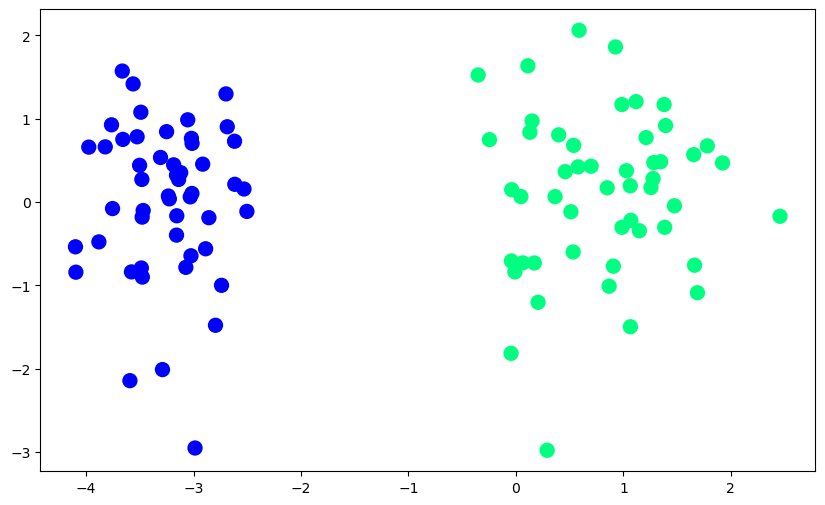

In [11]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [12]:
def step(x):
    return 1 if x >= 0 else 0

In [13]:
def perceptron(X,y):

    X=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    lr=0.1

    for i in range(1000):
        j=np.random.randint(0,100)
        y_hat=step(np.dot(X[j],weights))
        weights=weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [14]:
intercept,coeff=perceptron(X,y)

In [15]:
m=-(coeff[0]/coeff[1])
b=-(intercept/coeff[1])

In [16]:
x_input=np.linspace(-3,3,100)
y_input=m*x_input+b

In [17]:
from sklearn.linear_model import LogisticRegression
lor=LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [18]:
m=-(lor.coef_[0][0]/lor.coef_[0][1])
b=-(lor.intercept_/lor.coef_[0][1])

In [19]:
x_input1=np.linspace(-3,3,100)
y_input1=m*x_input+b

In [26]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [27]:
def perceptron(X,y):

    X=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    lr=0.1

    for i in range(1000):
        j=np.random.randint(0,100)
        y_hat=sigmoid(np.dot(X[j],weights))
        weights=weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [28]:
intercept,coeff=perceptron(X,y)

In [29]:
m=-(coeff[0]/coeff[1])
b=-(intercept/coeff[1])

In [30]:
x_input2=np.linspace(-3,3,100)
y_input2=m*x_input+b

(-3.0, 2.0)

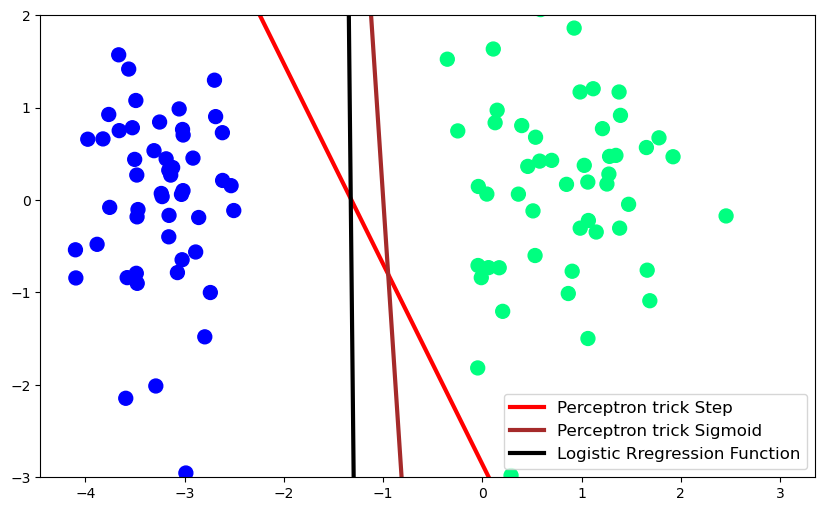

In [32]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3,label="Perceptron trick Step")
plt.plot(x_input2,y_input2,color='brown',linewidth=3,label="Perceptron trick Sigmoid")
plt.plot(x_input1,y_input1,color='black',linewidth=3,label="Logistic Rregression Function")
plt.legend(loc='best', fontsize=12)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)